In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv("Real estate.csv")

print(df.head())

   No  X1 transaction date  X2 house age  \
0   1             2012.917          32.0   
1   2             2012.917          19.5   
2   3             2013.583          13.3   
3   4             2013.500          13.3   
4   5             2012.833           5.0   

   X3 distance to the nearest MRT station  X4 number of convenience stores  \
0                                84.87882                               10   
1                               306.59470                                9   
2                               561.98450                                5   
3                               561.98450                                5   
4                               390.56840                                5   

   X5 latitude  X6 longitude  Y house price of unit area  
0     24.98298     121.54024                        37.9  
1     24.98034     121.53951                        42.2  
2     24.98746     121.54391                        47.3  
3     24.98746     121.54391  

In [2]:
def predict_and_plot(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    # Y_predict = model.predict(X)

    # # Predict values on training and test sets
    # Y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # R2 (R-squared)
    r2 = r2_score(y_test, y_test_pred)
    # RMSE (Root Mean Squared Error)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    # MAE (Mean Absolute Error)
    mae = mean_absolute_error(y_test, y_test_pred)
    # Regression equation
    slope = model.coef_[0]  # Coefficient
    intercept = model.intercept_  # Intercept

    print("=" * 50)
    print("REGRESSION EQUATION:")
    print(f"Price = {intercept[0]:.2f} + {slope[0]:.2f} × X attribute")
    print()
    print("PERFORMANCE METRICS (Test Set):")
    print(f"R²:   {r2:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print("=" * 50)

    # Plotting
    plt.scatter(X_train, y_train, color="green", label="Training Data")
    plt.scatter(X_test, y_test, color="blue", label="Testing Data")

    # Regression line over the full X range
    X_all = np.vstack((X_train, X_test))
    X_line = np.linspace(X_all.min(), X_all.max(), 100).reshape(-1, 1)
    Y_line = model.predict(X_line)
    plt.plot(X_line, Y_line, color="red", label="Regression Line")

    plt.xlabel("X attribute")
    plt.ylabel("Price")
    plt.title("Linear Regression: Training vs Testing")
    plt.legend()
    plt.grid(True)
    plt.show()

## Using House Age to predict Price

REGRESSION EQUATION:
Price = 42.88 + -0.26 × X attribute

PERFORMANCE METRICS (Test Set):
R²:   0.02
RMSE: 12.85
MAE:  10.62


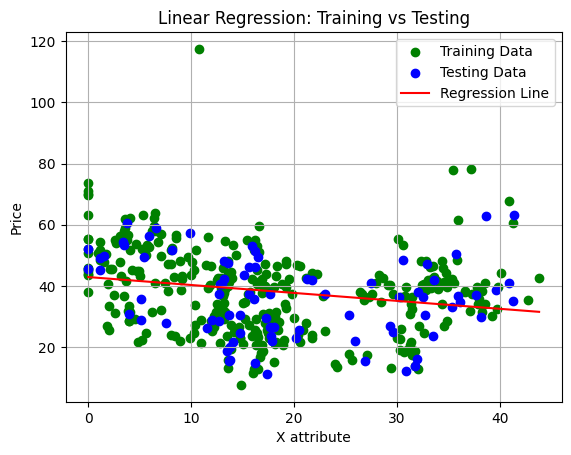

In [3]:
# Using House Age to predict Price
X = df["X2 house age"].values.reshape(-1, 1)
y = df["Y house price of unit area"].values.reshape(-1, 1)

predict_and_plot(X,y)


REGRESSION EQUATION:
Price = 0.32 + -0.10 × X attribute

PERFORMANCE METRICS (Test Set):
R²:   0.02
RMSE: 0.12
MAE:  0.10


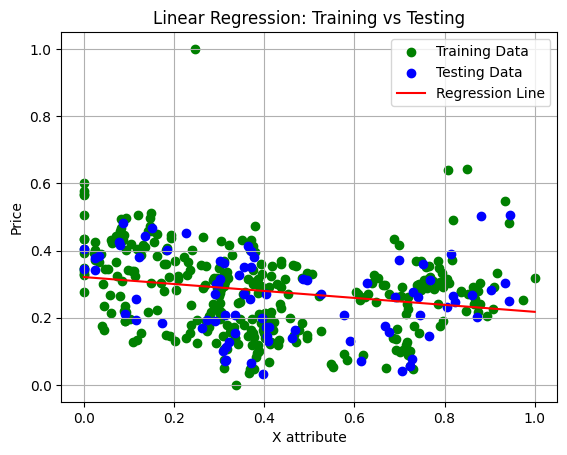

In [4]:
# min max scaling
X_normalized = (X - X.min()) / (X.max() - X.min())
y_normalized = (y - y.min()) / (y.max() - y.min())

predict_and_plot(X_normalized, y_normalized)

REGRESSION EQUATION:
Price = 0.02 + -0.22 × X attribute

PERFORMANCE METRICS (Test Set):
R²:   0.02
RMSE: 0.95
MAE:  0.78


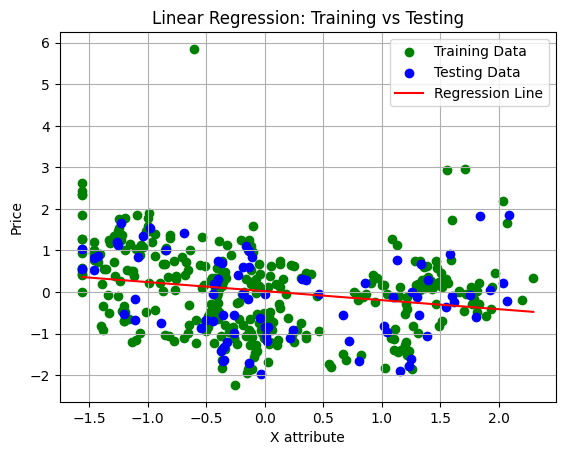

In [5]:
# mean normalization
X_mean_normalization = (X - X.mean()) / X.std()
y_mean_normalization = (y - y.mean()) / y.std()

predict_and_plot(X_mean_normalization, y_mean_normalization)

It appears that performing min-max scaling on the dataset before running it through the model yielded the lowest loss, making this the better model.
According to the graph, the price of a house tends to decrease as it gets older.

## Choosing other attributes

Here I'm choosing ` X3 distance to the nearest MRT station` and `X4 number of convenience stores` to study the correlation to `House Price`

 X3 distance to the nearest MRT station

REGRESSION EQUATION:
Price = 0.35 + -0.44 × X attribute

PERFORMANCE METRICS (Test Set):
R²:   0.54
RMSE: 0.08
MAE:  0.06


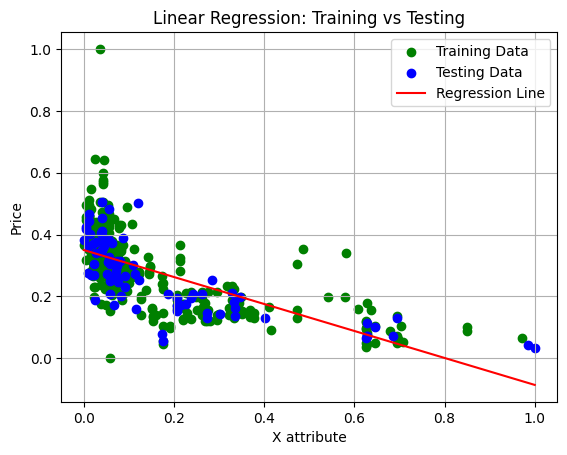

In [6]:
X = df["X3 distance to the nearest MRT station"].values.reshape(-1, 1)
y = df["Y house price of unit area"].values.reshape(-1, 1)
X_normalized = (X - X.min()) / (X.max() - X.min())
y_normalized = (y - y.min()) / (y.max() - y.min())

predict_and_plot(X_normalized, y_normalized)


Here we can see that the price of the houses drops quite fast the further it is from the nearest MRT station

X4 number of convenience stores

REGRESSION EQUATION:
Price = 0.18 + 0.23 × X attribute

PERFORMANCE METRICS (Test Set):
R²:   0.39
RMSE: 0.09
MAE:  0.08


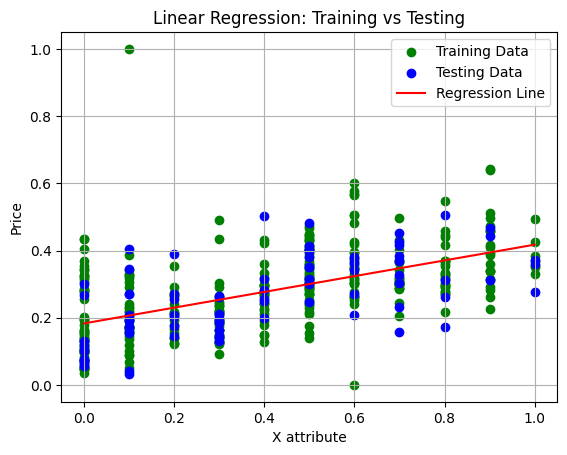

In [7]:
X = df["X4 number of convenience stores"].values.reshape(-1, 1)
y = df["Y house price of unit area"].values.reshape(-1, 1)
X_normalized = (X - X.min()) / (X.max() - X.min())
y_normalized = (y - y.min()) / (y.max() - y.min())

predict_and_plot(X_normalized, y_normalized)


The price increases the more convenience store nearby

## Training a multiple linear regression model

Multiple Linear Regression Results:
R² Score: 0.65
RMSE: 0.07
MAE: 0.05

Feature Coefficients:
X2 house age: -0.10
X3 distance to the nearest MRT station: -0.32
X4 number of convenience stores: 0.11
Intercept: 0.33


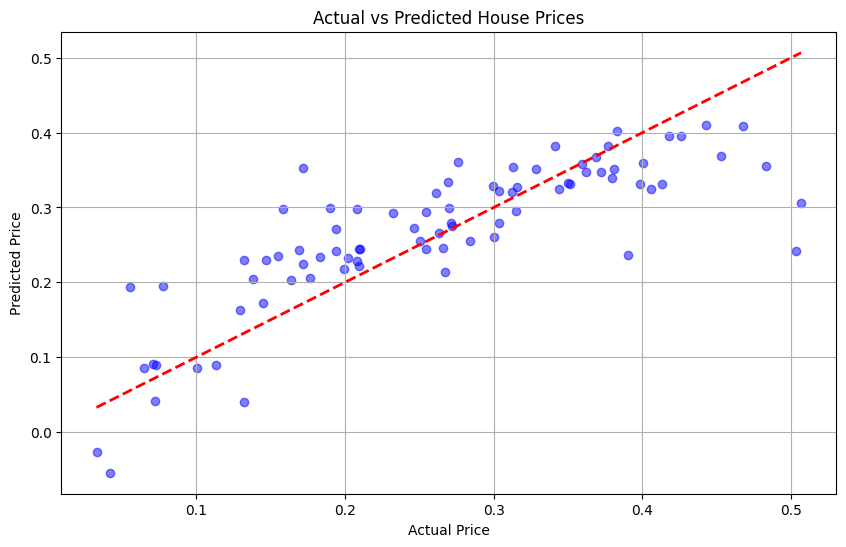

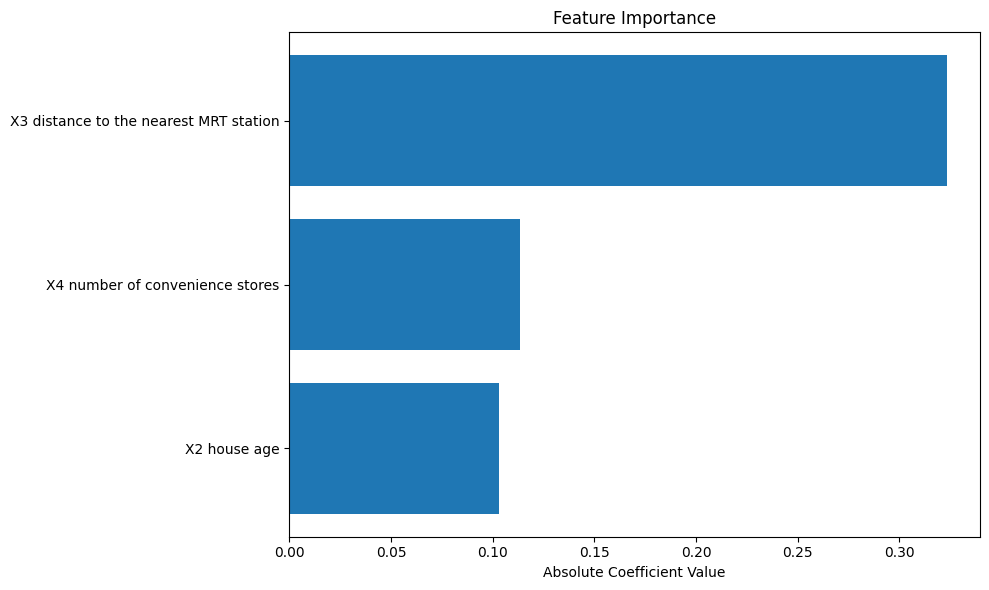

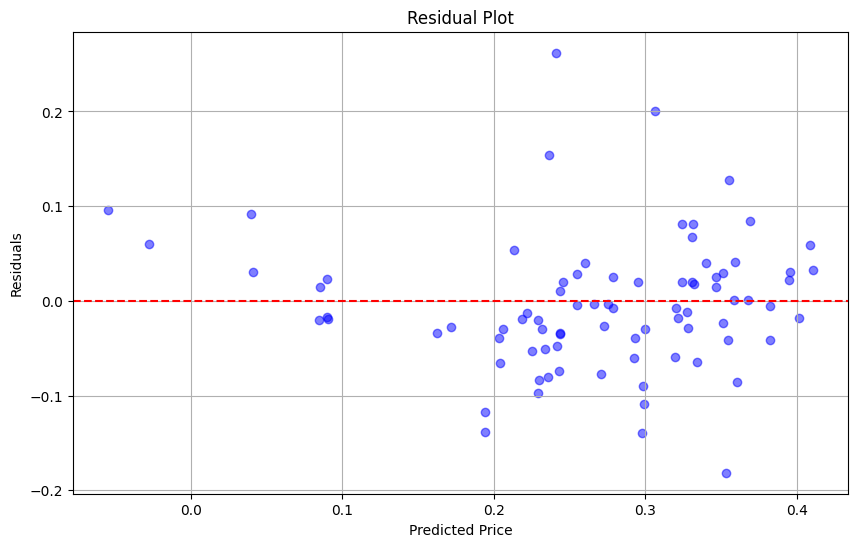

In [25]:
X = df.drop(
    columns=[
        "No",
        "X1 transaction date",
        "X5 latitude",
        "X6 longitude",
        "Y house price of unit area",
    ]
)
y = df["Y house price of unit area"]

X_normalized = (X - X.min()) / (X.max() - X.min())
y_normalized = (y - y.min()) / (y.max() - y.min())

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_normalized, test_size=0.2, random_state=42
)


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("Multiple Linear Regression Results:")
print(f"R² Score: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print("=" * 50)
print("\nFeature Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.2f}")
# print(f"Intercept: {model.intercept_:.2f}")
print("=" * 50)

# 1. Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color="blue", alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()

# 2. Feature Importance Plot
coefficients = pd.DataFrame({"Feature": X.columns, "Coefficient": abs(model.coef_)})
coefficients = coefficients.sort_values("Coefficient", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.xlabel("Absolute Coefficient Value")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# 3. Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, color="blue", alpha=0.5)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

- Lower RMSE and MAE ([0.07,0.05] vs [0.09,0.08],[0.08,0.06],[0.12,0.1]) => better accuracy
- Higher R² (0.65 vs 0.39, 0.54, 0.02) => better fit
